# Emotion classification from text (Custom RCNN)

This notebook keeps the same dataset, preprocessing outline, training flow, evaluation, and error-analysis structure as the original BiLSTM notebook. The main change is the model: the BiLSTM classifier is replaced with a **custom RCNN-style text classifier** that combines recurrent contextual encoding, convolutional n-gram feature extraction, attention pooling, and max pooling.


## 1. Setup


In [1]:
# Import libraries
import os
import re
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from datasets import load_dataset
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    f1_score,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [2]:
# Load dataset
raw = load_dataset("mteb/emotion")


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/128k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/15956 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1988 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1986 [00:00<?, ? examples/s]

## 2. EDA


Columns: ['text', 'label', 'label_text']

Rows — train: 15956 | val: 1988 | test: 1986

First rows (train):


,text,label,label_text
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger


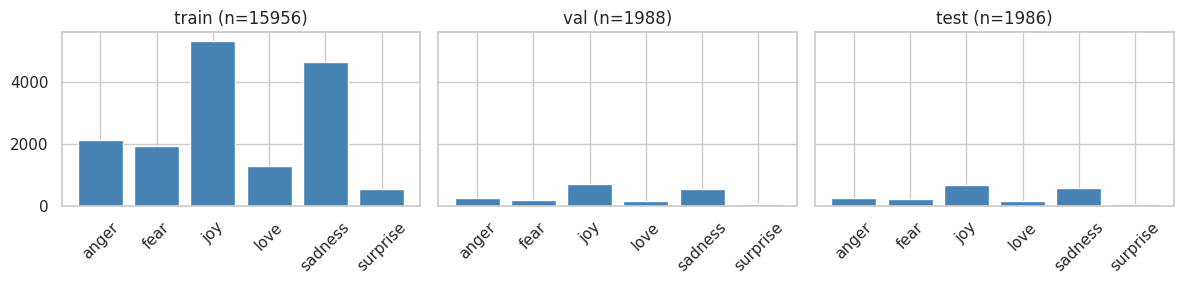


Random samples per class (train):
[sadness] i sort of feel like one of those people who was unfortunate and lost their father when they were and life goes on
[joy] i cant help but feel as though perhaps my perception isnt as keen as i once thought
[love] i was like that i always wanted to feel and be accepted by my family and others
[anger] i was feeling frustrated at work wondering if i am living a life with meaning and purpose
[fear] i almost feel intimidated by the attempt to describe it
[surprise] i was talking to my district leader elder hill last night and was explaining to him some of my concerns such as not seeing the fruits of our efforts not having baptized anyone yet and just plain feeling like i have so many problems and weaknesses that its not even funny


In [3]:
# EDA
def hf_to_df(split_name):
    d = raw[split_name]
    return pd.DataFrame({"text": d["text"], "label": d["label"], "label_text": d["label_text"]})

train_df = hf_to_df("train")
val_df = hf_to_df("validation")
test_df = hf_to_df("test")

print("Columns:", list(train_df.columns))
print("\nRows — train:", len(train_df), "| val:", len(val_df), "| test:", len(test_df))
print("\nFirst rows (train):")
display(train_df.head(3))

# Class distribution
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, (name, df) in zip(axes, [("train", train_df), ("val", val_df), ("test", test_df)]):
    vc = df["label_text"].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values, color="steelblue")
    ax.set_title(f"{name} (n={len(df)})")
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# Sample examples per class
print("\nRandom samples per class (train):")
for lab in sorted(train_df["label"].unique()):
    sub = train_df[train_df["label"] == lab]
    row = sub.sample(1, random_state=SEED).iloc[0]
    print(f"[{row['label_text']}] {row['text']}")


## 3. Text preprocessing


In [4]:
def preprocess(text: str, lowercase: bool = True) -> str:
    """
    Lightweight preprocessing is used to preserve the original text signal.
    For this dataset, aggressive cleaning can remove emotional cues, so the function
    mainly lowercases text and normalises whitespace.
    """
    t = str(text).strip()
    if lowercase:
        t = t.lower()
    t = re.sub(r"\s+", " ", t)
    return t

# Preview
ex = train_df["text"].iloc[10]
print("Before:", ex)
print("After :", preprocess(ex))


Before: i feel like i have to make the suffering i m seeing mean something
After : i feel like i have to make the suffering i m seeing mean something


## 4. Label preparation


In [5]:
labels_sorted = sorted(train_df["label"].unique())
assert labels_sorted == list(range(len(labels_sorted))), "Labels should be 0..K-1"
num_classes = len(labels_sorted)
id2label = train_df.drop_duplicates("label").set_index("label")["label_text"].to_dict()
label2id = {v: k for k, v in id2label.items()}
print("num_classes:", num_classes)
print("id2label:", id2label)


num_classes: 6
id2label: {0: 'sadness', 3: 'anger', 2: 'love', 5: 'surprise', 4: 'fear', 1: 'joy'}


## 5. Split dataset


In [6]:
train_df["text_proc"] = train_df["text"].map(preprocess)
val_df["text_proc"] = val_df["text"].map(preprocess)
test_df["text_proc"] = test_df["text"].map(preprocess)

print("Split sizes:", len(train_df), len(val_df), len(test_df))


Split sizes: 15956 1988 1986


## 6. Vocabulary & sequences


In [7]:
# Special tokens
PAD, UNK = "<pad>", "<unk>"

# Keep more vocabulary than the original BiLSTM version.
# min_freq=1 usually helps this dataset because short emotion texts often contain rare but meaningful words.
min_freq = 1


def build_vocab(texts, min_freq=min_freq):
    """
    Build a word-to-id vocabulary from training texts only.

    Args:
        texts: iterable of processed text strings
        min_freq: minimum number of times a word must appear to be included in the vocabulary

    Returns:
        vocab: dict mapping token -> integer id
    """
    cnt = Counter()
    for t in texts:
        cnt.update(t.split())
    vocab = {PAD: 0, UNK: 1}
    for w, c in cnt.items():
        if c >= min_freq:
            vocab[w] = len(vocab)
    return vocab


def texts_to_ids(texts, vocab, max_len):
    """
    Convert text strings into fixed-length sequences of token ids. Steps:
    1. Split each text into words
    2. Convert each word to its id using vocab - if word not found, use <unk> id
    3. Truncate sequence to max_len if too long
    4. Pad sequence with <pad> id if too short
    """
    pad_id = vocab[PAD]
    unk_id = vocab[UNK]
    X = []
    for t in texts:
        ids = [vocab.get(w, unk_id) for w in t.split()]
        ids = ids[:max_len]
        ids = ids + [pad_id] * max(0, max_len - len(ids))
        X.append(ids)
    return np.array(X, dtype=np.int64)


vocab = build_vocab(train_df["text_proc"], min_freq=min_freq)
vocab_size = len(vocab)
pad_id = vocab[PAD]

# Use a data-driven max length. The 95th percentile keeps most sentences while reducing unnecessary padding.
train_lengths = train_df["text_proc"].str.split().map(len)
max_len = int(np.percentile(train_lengths, 95))
max_len = max(20, min(max_len, 80))

X_train = texts_to_ids(train_df["text_proc"], vocab, max_len)
X_val = texts_to_ids(val_df["text_proc"], vocab, max_len)
X_test = texts_to_ids(test_df["text_proc"], vocab, max_len)

y_train = train_df["label"].to_numpy(dtype=np.int64)
y_val = val_df["label"].to_numpy(dtype=np.int64)
y_test = test_df["label"].to_numpy(dtype=np.int64)

print("Vocabulary size:", vocab_size)
print("Max sequence length:", max_len)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


Vocabulary size: 15212
Max sequence length: 41
X_train shape: (15956, 41)
y_train shape: (15956,)


In [8]:
sample_text = train_df["text_proc"].iloc[69]
sample_ids = texts_to_ids([sample_text], vocab, max_len)[0]

print("Original text:")
print(sample_text)

print("\nWords:")
print(sample_text.split())

print("\nToken IDs:")
print(sample_ids)

print("\nLength after padding/truncation:")
print(len(sample_ids))


Original text:
i was feeling brave when i bought it and clearly when i was doing my makeup

Words:
['i', 'was', 'feeling', 'brave', 'when', 'i', 'bought', 'it', 'and', 'clearly', 'when', 'i', 'was', 'doing', 'my', 'makeup']

Token IDs:
[  2  53   9 373 236   2 581  40  21 582 236   2  53 168 179 583   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0]

Length after padding/truncation:
41


## 7. PyTorch Dataset / DataLoader


In [9]:
class EmotionDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


def make_loader(X, y, batch_size, shuffle=False, sampler=None):
    ds = EmotionDataset(X, y)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle if sampler is None else False, sampler=sampler)


BATCH_SIZE = 128

# Weighted sampler helps the model see minority emotion classes more often during training.
class_counts = np.bincount(y_train, minlength=num_classes)
sample_weights = 1.0 / class_counts[y_train]
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)

train_loader = make_loader(X_train, y_train, BATCH_SIZE, sampler=sampler)
val_loader = make_loader(X_val, y_val, BATCH_SIZE, shuffle=False)
test_loader = make_loader(X_test, y_test, BATCH_SIZE, shuffle=False)

print("Class counts:", class_counts)


Class counts: [4663 5345 1297 2152 1931  568]


## 8. Custom RCNN model


In [10]:
# Custom RCNN model for text emotion classification
# In NLP, RCNN usually means Recurrent Convolutional Neural Network.
# This custom model combines:
# 1. Embedding layer for word vectors
# 2. Bidirectional recurrent layer for context before and after each token
# 3. Convolution layers over contextual token representations to capture local n-gram emotion patterns
# 4. Attention pooling and max pooling to produce a strong sentence representation
# 5. Multi-layer classifier with dropout and layer normalisation

class AttentionPooling(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.score = nn.Linear(input_dim, 1)

    def forward(self, x, mask):
        # x shape: (B, T, D)
        # mask shape: (B, T), True for real tokens and False for padding
        scores = self.score(x).squeeze(-1)
        scores = scores.masked_fill(~mask, -1e9)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        pooled = torch.sum(x * weights, dim=1)
        return pooled


class CustomRCNNClassifier(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        num_classes,
        padding_idx,
        rnn_layers=2,
        cnn_filters=128,
        kernel_sizes=(2, 3, 4),
        dropout=0.45,
    ):
        super().__init__()
        self.padding_idx = padding_idx

        # Embedding layer
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
        self.embedding_dropout = nn.Dropout(dropout)

        # Bidirectional recurrent encoder
        self.rnn = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=rnn_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if rnn_layers > 1 else 0.0,
        )

        rnn_out_dim = hidden_dim * 2
        self.rnn_norm = nn.LayerNorm(rnn_out_dim)

        # Convolutional feature extractors over contextual recurrent outputs
        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=rnn_out_dim,
                out_channels=cnn_filters,
                kernel_size=k,
                padding="same",
            )
            for k in kernel_sizes
        ])

        conv_out_dim = cnn_filters * len(kernel_sizes)
        self.attention = AttentionPooling(rnn_out_dim)

        # Combine attention-pooled recurrent features and max-pooled CNN features
        classifier_in = rnn_out_dim + conv_out_dim
        self.classifier = nn.Sequential(
            nn.Linear(classifier_in, 256),
            nn.ReLU(),
            nn.LayerNorm(256),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout * 0.7),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        # x shape: (B, T)
        mask = x != self.padding_idx

        # Embedding
        emb = self.embedding_dropout(self.embed(x))

        # Recurrent contextual encoding
        rnn_out, _ = self.rnn(emb)             # (B, T, 2H)
        rnn_out = self.rnn_norm(rnn_out)

        # Attention pooling over recurrent features
        attn_pool = self.attention(rnn_out, mask)  # (B, 2H)

        # CNN expects (B, channels, T)
        conv_input = rnn_out.transpose(1, 2)       # (B, 2H, T)
        conv_features = []
        for conv in self.convs:
            c = F.relu(conv(conv_input))           # (B, filters, T)
            c = F.max_pool1d(c, kernel_size=c.size(2)).squeeze(2)
            conv_features.append(c)
        cnn_pool = torch.cat(conv_features, dim=1)

        # Final sentence representation
        features = torch.cat([attn_pool, cnn_pool], dim=1)
        logits = self.classifier(features)
        return logits


In [11]:
# Optional quick sanity check: one mini-batch should produce logits of shape (batch_size, num_classes)
xb, yb = next(iter(train_loader))
tmp_model = CustomRCNNClassifier(
    vocab_size=vocab_size,
    embed_dim=200,
    hidden_dim=128,
    num_classes=num_classes,
    padding_idx=pad_id,
).to(device)
with torch.no_grad():
    out = tmp_model(xb.to(device))
print("Mini-batch shape:", xb.shape)
print("Logits shape:", out.shape)
del tmp_model


Mini-batch shape: torch.Size([128, 41])
Logits shape: torch.Size([128, 6])


## 9. Training - weighted CrossEntropyLoss, AdamW, early stopping on val macro-F1


In [12]:
# Train the model for one epoch
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad(set_to_none=True)

        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()

        # Gradient clipping improves stability for recurrent models
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        total_loss += loss.item() * xb.size(0)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    total_loss = 0.0
    all_y, all_p = [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)

        if criterion is not None:
            total_loss += criterion(logits, yb).item() * xb.size(0)

        all_p.append(logits.argmax(dim=-1).cpu().numpy())
        all_y.append(yb.cpu().numpy())

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_p)

    metrics = {
        "acc": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro"),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }

    if criterion is not None:
        metrics["loss"] = total_loss / len(loader.dataset)

    return metrics, y_true, y_pred


# Training loop with validation, class-weighted loss, scheduler, and early stopping
def train_model(
    model,
    train_loader,
    val_loader,
    epochs=35,
    lr=8e-4,
    weight_decay=1e-4,
    patience=6,
):
    # Class weights reduce bias toward majority labels.
    weights = len(y_train) / (num_classes * np.bincount(y_train, minlength=num_classes))
    class_weights = torch.tensor(weights, dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
    )

    history = {"train_loss": [], "val_loss": [], "val_macro_f1": [], "val_acc": []}
    best_state = None
    best_f1 = -1.0
    stale = 0

    for ep in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_metrics, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step(val_metrics["macro_f1"])

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_macro_f1"].append(val_metrics["macro_f1"])
        history["val_acc"].append(val_metrics["acc"])

        if val_metrics["macro_f1"] > best_f1 + 1e-5:
            best_f1 = val_metrics["macro_f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            stale = 0
        else:
            stale += 1

        current_lr = optimizer.param_groups[0]["lr"]
        print(
            f"Epoch {ep:02d} "
            f"train_loss={train_loss:.4f} "
            f"val_loss={val_metrics['loss']:.4f} "
            f"val_acc={val_metrics['acc']:.4f} "
            f"val_macro_f1={val_metrics['macro_f1']:.4f} "
            f"lr={current_lr:.6f}"
        )

        if stale >= patience:
            print(f"Early stopping at epoch {ep} because validation macro-F1 did not improve for {patience} epochs.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_f1


def plot_history(history, title="Training history"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["train_loss"], label="train loss")
    plt.plot(epochs, history["val_loss"], label="val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " — loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["val_macro_f1"], label="val macro-F1")
    plt.plot(epochs, history["val_acc"], label="val accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title(title + " — validation scores")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 10. Train Custom RCNN


Epoch 01 train_loss=1.3889 val_loss=1.6379 val_acc=0.1373 val_macro_f1=0.1457 lr=0.000800
Epoch 02 train_loss=0.9470 val_loss=1.4029 val_acc=0.2233 val_macro_f1=0.2736 lr=0.000800
Epoch 03 train_loss=0.7640 val_loss=1.2171 val_acc=0.3053 val_macro_f1=0.3769 lr=0.000800
Epoch 04 train_loss=0.6316 val_loss=1.0704 val_acc=0.3375 val_macro_f1=0.4388 lr=0.000800
Epoch 05 train_loss=0.5803 val_loss=0.9282 val_acc=0.6026 val_macro_f1=0.6677 lr=0.000800
Epoch 06 train_loss=0.5302 val_loss=0.8407 val_acc=0.6403 val_macro_f1=0.6963 lr=0.000800
Epoch 07 train_loss=0.4745 val_loss=0.7713 val_acc=0.7259 val_macro_f1=0.7651 lr=0.000800
Epoch 08 train_loss=0.4445 val_loss=0.7277 val_acc=0.7475 val_macro_f1=0.7874 lr=0.000800
Epoch 09 train_loss=0.4079 val_loss=0.6585 val_acc=0.8390 val_macro_f1=0.8424 lr=0.000800
Epoch 10 train_loss=0.3938 val_loss=0.6285 val_acc=0.8602 val_macro_f1=0.8550 lr=0.000800
Epoch 11 train_loss=0.3745 val_loss=0.6204 val_acc=0.8642 val_macro_f1=0.8508 lr=0.000800
Epoch 12 t

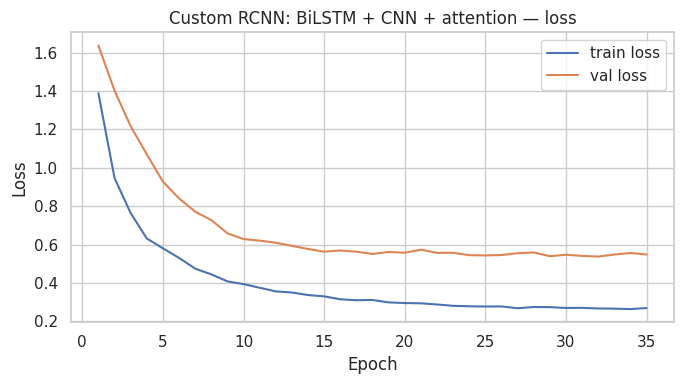

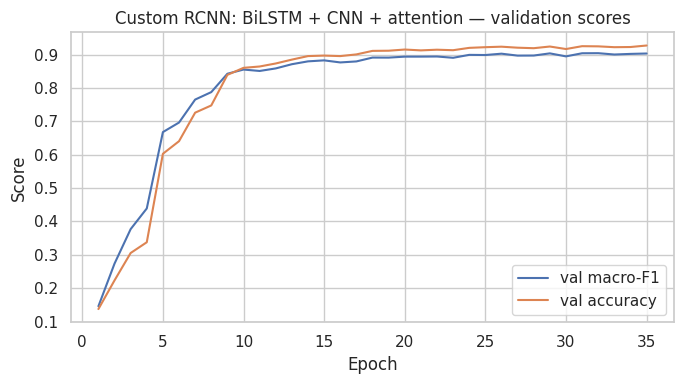

In [13]:
# Set random seed for reproducibility
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Custom RCNN hyperparameters selected for stronger performance on short emotion texts.
main_model = CustomRCNNClassifier(
    vocab_size=vocab_size,
    embed_dim=200,
    hidden_dim=128,
    num_classes=num_classes,
    padding_idx=pad_id,
    rnn_layers=2,
    cnn_filters=128,
    kernel_sizes=(2, 3, 4),
    dropout=0.45,
).to(device)

hist_main, best_val_f1 = train_model(
    main_model,
    train_loader,
    val_loader,
    epochs=35,
    lr=8e-4,
    weight_decay=1e-4,
    patience=6,
)

print("Best val macro-F1 (Custom RCNN):", best_val_f1)
plot_history(hist_main, title="Custom RCNN: BiLSTM + CNN + attention")


## 11. Evaluation


=== Validation Custom RCNN ===
Accuracy: 0.9245472837022133

Per-class precision/recall/F1:
  sadness     P=0.962  R=0.933  F1=0.947
  joy         P=0.994  R=0.900  F1=0.945
  love        P=0.783  R=1.000  F1=0.878
  anger       P=0.905  R=0.942  F1=0.923
  fear        P=0.863  R=0.896  F1=0.879
  surprise    P=0.781  R=0.938  F1=0.852

Macro / weighted F1: 0.9040813606347607 0.9259227971702461

               precision    recall  f1-score   support

     sadness      0.962     0.933     0.947       550
         joy      0.994     0.900     0.945       700
        love      0.783     1.000     0.878       173
       anger      0.905     0.942     0.923       274
        fear      0.863     0.896     0.879       211
    surprise      0.781     0.938     0.852        80

    accuracy                          0.925      1988
   macro avg      0.881     0.935     0.904      1988
weighted avg      0.932     0.925     0.926      1988



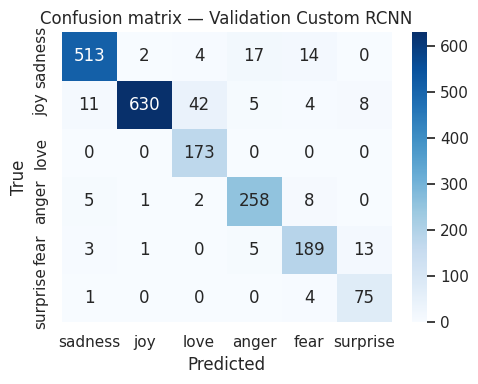

=== Test Custom RCNN ===
Accuracy: 0.9249748237663645

Per-class precision/recall/F1:
  sadness     P=0.986  R=0.945  F1=0.965
  joy         P=0.992  R=0.895  F1=0.941
  love        P=0.724  R=0.994  F1=0.838
  anger       P=0.923  R=0.956  F1=0.939
  fear        P=0.889  R=0.893  F1=0.891
  surprise    P=0.655  R=0.877  F1=0.750

Macro / weighted F1: 0.8872796061766257 0.9277029502738646

               precision    recall  f1-score   support

     sadness      0.986     0.945     0.965       579
         joy      0.992     0.895     0.941       688
        love      0.724     0.994     0.838       156
       anger      0.923     0.956     0.939       274
        fear      0.889     0.893     0.891       224
    surprise      0.655     0.877     0.750        65

    accuracy                          0.925      1986
   macro avg      0.861     0.927     0.887      1986
weighted avg      0.937     0.925     0.928      1986



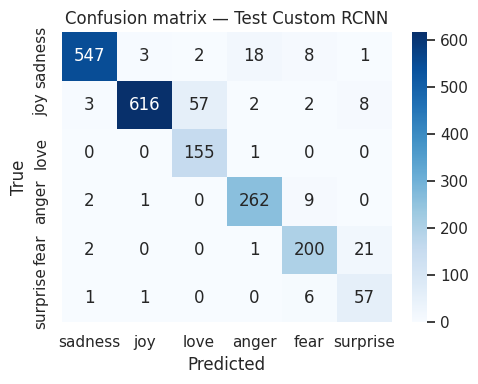

array([[547,   3,   2,  18,   8,   1],
       [  3, 616,  57,   2,   2,   8],
       [  0,   0, 155,   1,   0,   0],
       [  2,   1,   0, 262,   9,   0],
       [  2,   0,   0,   1, 200,  21],
       [  1,   1,   0,   0,   6,  57]])

In [14]:
def full_report(y_true, y_pred, split_name="val"):
    """
    Print a full classification report and plot the confusion matrix.

    Args:
        y_true: true labels
        y_pred: predicted labels
        split_name: name of the data split, e.g. 'validation' or 'test'

    Returns:
        cm: confusion matrix as a NumPy array
    """
    names = [id2label[i] for i in sorted(id2label.keys())]

    print(f"=== {split_name} ===")
    print("Accuracy:", accuracy_score(y_true, y_pred))

    p, r, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average=None,
        labels=sorted(id2label.keys()),
        zero_division=0,
    )

    print("\nPer-class precision/recall/F1:")
    for i, lab in enumerate(sorted(id2label.keys())):
        print(f"  {names[i]:10s}  P={p[i]:.3f}  R={r[i]:.3f}  F1={f1[i]:.3f}")

    print(
        "\nMacro / weighted F1:",
        f1_score(y_true, y_pred, average="macro"),
        f1_score(y_true, y_pred, average="weighted"),
    )

    print("\n", classification_report(y_true, y_pred, target_names=names, digits=3, zero_division=0))

    cm = confusion_matrix(y_true, y_pred, labels=sorted(id2label.keys()))

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=names,
        yticklabels=names,
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"Confusion matrix — {split_name}")
    plt.tight_layout()
    plt.show()

    return cm


criterion_eval = nn.CrossEntropyLoss()
_, yv_t, yv_p = evaluate(main_model, val_loader, criterion_eval)
full_report(yv_t, yv_p, "Validation Custom RCNN")

_, yt_t, yt_p = evaluate(main_model, test_loader, criterion_eval)
full_report(yt_t, yt_p, "Test Custom RCNN")


## 12. Error analysis


In [15]:
# Run evaluation on the validation set
_, yv_t, yv_p = evaluate(main_model, val_loader, None)

# Create ordered class names from label ids
names = [id2label[i] for i in sorted(id2label.keys())]

# Build confusion matrix
cm = confusion_matrix(yv_t, yv_p, labels=sorted(id2label.keys()))

# Find the most common confusion pairs
pairs = []
n = cm.shape[0]
for i in range(n):
    for j in range(n):
        if i != j and cm[i, j] > 0:
            pairs.append((cm[i, j], names[i], names[j]))
pairs.sort(reverse=True)

# Print the most frequent confusion types
print("Top confused (true -> pred):")
for c, a, b in pairs[:8]:
    print(f"  {c:4d}  {a} -> {b}")

# Show some actual misclassified validation examples
val_texts = val_df["text_proc"].to_numpy()
wrong_idx = np.where(yv_t != yv_p)[0]

if len(wrong_idx) == 0:
    print("No validation errors found.")
else:
    sample = np.random.default_rng(SEED).choice(wrong_idx, size=min(12, len(wrong_idx)), replace=False)
    print("\nSample errors (val):")
    for i in sample:
        print(f"\n true={names[yv_t[i]]} pred={names[yv_p[i]]}")
        print(" ", val_texts[i][:280])


Top confused (true -> pred):
    42  joy -> love
    17  sadness -> anger
    14  sadness -> fear
    13  fear -> surprise
    11  joy -> sadness
     8  joy -> surprise
     8  anger -> fear
     5  joy -> anger

Sample errors (val):

 true=sadness pred=fear
  i find myself trying to discreetly smell his breath but then feel guilty for being so suspicious

 true=fear pred=surprise
  i was feeling pretty strange like dinosaur soldier after i read them because in a weird sort of adult or perhaps college aged way my brain was analyzing the books

 true=sadness pred=anger
  when my grandmother died after a long illness

 true=joy pred=love
  i feel generous and remain composed

 true=fear pred=sadness
  that day i was alone at home after coming home from school i did not know where everyone else had gone

 true=fear pred=anger
  i feeling soo agitated

 true=joy pred=love
  i have stayed at heritage christian because of the fulfillment that i feel in doing christ s work in action by being

## 13. Notes on the custom RCNN configuration


In [16]:
print(
    "This custom RCNN is configured to improve performance by combining several changes:\n"
    "1. min_freq=1 keeps rare emotion words instead of removing them.\n"
    "2. WeightedRandomSampler and class-weighted loss reduce majority-class bias.\n"
    "3. The recurrent encoder captures word order and context.\n"
    "4. CNN filters with kernel sizes 2, 3, and 4 capture local phrase patterns.\n"
    "5. Attention pooling highlights the most emotionally informative tokens.\n"
    "6. AdamW, label smoothing, LR scheduling, dropout, and early stopping improve generalisation."
)


This custom RCNN is configured to improve performance by combining several changes:
1. min_freq=1 keeps rare emotion words instead of removing them.
2. WeightedRandomSampler and class-weighted loss reduce majority-class bias.
3. The recurrent encoder captures word order and context.
4. CNN filters with kernel sizes 2, 3, and 4 capture local phrase patterns.
5. Attention pooling highlights the most emotionally informative tokens.
6. AdamW, label smoothing, LR scheduling, dropout, and early stopping improve generalisation.
